This notebook processes the two replicates of the cohen retina scMPRA dataset into an ortho object.

# Setup

In [1]:
import scMPRAforge as scm

2025-10-27 10:46:49.729841: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 10:46:50.631050: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
#create dask cluster

#from dask_jobqueue import SLURMCluster
#from dask.distributed import Client

#cluster=SLURMCluster(
#    cores=4,#cores per slurm job
#    memory="64G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=9:00:00",
#        f"--output=slave_%j.out"]
#)
#
#cluster.scale(jobs=6)
#
#client = Client(cluster,
#        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
#        heartbeat_interval="30s"  # Worker heartbeat interval
#    )

from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='24GB')
client = Client(cluster)

# Describe with an ortho

Regarding reference cell-type,
> Reproducibility was highest in rod cells (Spearman’s ρ = 0.97, Pearson’s R = 0.98) because rod cells are the most abundant cell type in the mouse retina.

Regarding negative controls 
> In this experiment, we define the effect of a mutation as its relative fold-change to the WT Gnb3 promoter in each cell type because the Gnb3 promoter is expressed at different levels across cell types (Fig. 5a).

Interestingly, there are two wt promoters. Some code in the cohen paper's zenodo (`Part2_section6_retina_analysis.ipynb`) suggests that they should be treated together:

```
rep1_wt_df = rep1_exp.loc[rep1_exp['name'].str.contains('wt')]
mean_exp = np.mean(rep1_wt_df['mean'])
rep1_exp['activity'] = rep1_exp['mean']/mean_exp
```

So we will simply lump both, despite the fact that they have different sequences.

In [3]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
path="/gpfs/gibbs/pi/reilly/tabula_data/cohen"
name="ortho_primordial"


import os
if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
else:
    print("[+] Model not found. Creating...")

    #load data
    cohen=scm.scMPRA_data.from_parquet(f"{path}/retina_single_counting_u6.scmpra")
    cohen.set_negative_controls(["wt_1","wt_2"])
    cohen.set_reference_cell("Rod")
    cohen.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=cohen)
    primordial.extract_params(client)
    primordial.save(path,name)


[+] Model found. Loading...


In [22]:
client.dashboard_link

'http://127.0.0.1:8787/status'

Examining QC metrics : mean VS estimated parameter

In [5]:
primordial.compute_model_qc()

In [24]:
import numpy as np

Key,Copies,Workers
_label_tensorzinb_regressors-ead2c04ef298f3d8b080b81aede564fb,0,


In [7]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

by_cell_type_thetas=[]
for key in primordial.by_cell_type.model:
    by_cell_type_thetas.append(primordial.by_cell_type.model[key].result()["weights"]["theta"].squeeze())
by_cell_type_thetas=np.array(by_cell_type_thetas)


In [9]:
import seaborn as sns

<Axes: >

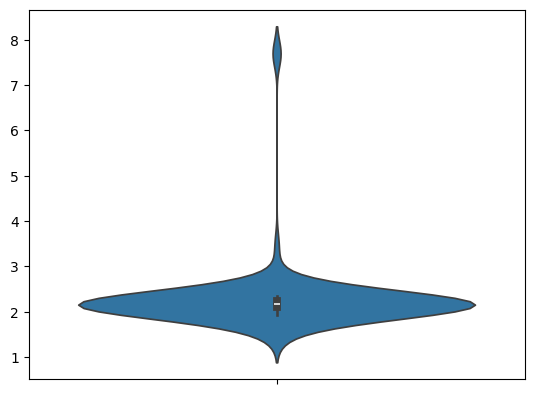

In [10]:
sns.violinplot(by_cre_thetas)

<Axes: >

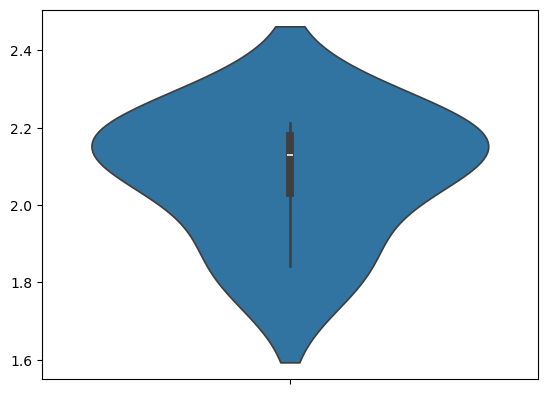

In [11]:
sns.violinplot(by_cell_type_thetas)

In [12]:
import pandas as pd

In [13]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 0.24882659417783423, max 1.7533656620982856
ct
min 0.24863474105825842, max 1.7567511164117384


That seems way too low?

---
---
[0.999988285011918, 0.9999999223715385, 0.9999995386416882, 0.9999916231113103, 0.9999988997258566, 0.9999985401540789, 0.99999990021365, 0.999993189886044, 0.9999599344278027, 0.9999998376111847, 0.9999933658683003, 0.9999842245843845, 0.9999989681094295, 0.9999977687748571, 0.9999849769129656, 0.9999938764352196, 0.9999998835153115, 0.999997431595629, 0.9999719775872455, 0.9999890874310448, 0.9999910733320573, 0.9999836195297425, 0.9999995040201453, 0.9999773588338453, 0.9999993895420703, 0.9999985077403172, 0.9999966810164922, 0.9999929175917806, 0.9999980939923477, 0.9999960781887441, 0.9999989421260805, 0.9999929556625805, 0.9999984112030949, 0.9999980901652202, 0.9999955560099452, 0.9999968886730904, 0.9999991774493836, 0.9999991315097264, 0.9999964221223575, 0.999991090629433, 0.9999960868695905, 0.9999946615663333, 0.9999984958155512, 0.9999902548479354, 0.9999987396677481, 0.9999826259588719, 0.9999548284214413, 0.9999966181881798, 0.9999794408695258, 0.999984820644457

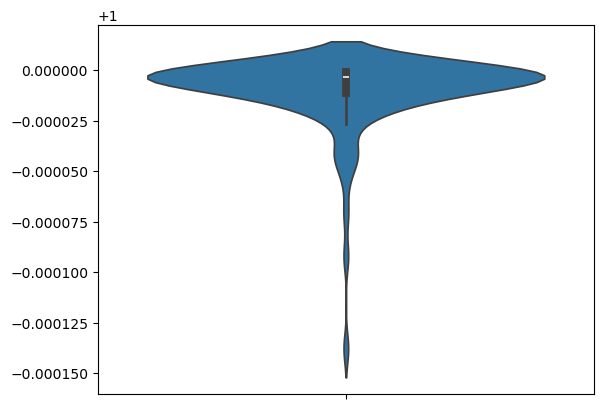

In [14]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)

In [15]:
print(min(r))

0.9998622688059512


But the correlations are high...

In [19]:
primordial.by_cell_type_parameters.zi["reference"].result()

,zi
rep_id,
1,0.000025
2,0.000017


Zi is very low... I expect that zero deflation due to ascertainment bias predominates over zero inflation due to dropout... At least in this dataset.

The data are very 1 heavy, leading to most CREs having a distribution 

How would better barcode matching affect the count distribution?

- It would reduce the number of unique umis, making umis_mpra_bc MORE 1-heavy 
- It would smush together some MPRA barcodes, making the data LESS 1-heavy
- It would smush together some cell barcodes, making the data LESS 1-heavy


In [ ]:
cluster.close()
client.close()